# Cargo Transfer Delay Prediction

# Part 1: Data Exploration

## 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from scipy import stats
from IPython.display import display
import os
import shutil

# Set random seed for reproducibility
np.random.seed(42)

# Load data using relative paths (use `data/` directory)
data_path = 'data/'
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))

Using data_path: data/


### Data loading complete

The training and test datasets were loaded from the local `data/` directory.

## 2. Data Overview

This section provides a high-level understanding of the dataset structure, including shape, data types, and basic statistical information. Understanding data dimensions and types is crucial for identifying potential data quality issues and planning preprocessing steps.

In [66]:
# Display dataset info
print("Dataset Information:")
train_df.info()

print("\n---")
# Display basic statistics for numerical features
print("\nBasic Statistics:")
display(train_df.describe())

print("\n---")
# Display missing data identification
print("\nMissing Data Identification:")
missing_counts = train_df.isnull().sum()
missing_data = missing_counts[missing_counts > 0].sort_values(ascending=False)
if not missing_data.empty:
    display(missing_data)
else:
    print("No missing values found.")

print("\n---")
# Display sample rows
print("\nSample Rows:")
display(train_df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51056 entries, 0 to 51055
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   transfer_id                       51056 non-null  object 
 1   operation_date                    51056 non-null  object 
 2   day_of_week                       51056 non-null  int64  
 3   scheduled_dispatch_time           51056 non-null  int64  
 4   actual_dispatch_time              47883 non-null  float64
 5   dispatch_delay_minutes            50436 non-null  float64
 6   scheduled_arrival_time            51056 non-null  int64  
 7   actual_arrival_time               47827 non-null  float64
 8   source_facility                   51056 non-null  object 
 9   source_region                     51056 non-null  object 
 10  destination_facility              51056 non-null  object 
 11  destination_region                51056 non-nu

,day_of_week,scheduled_dispatch_time,actual_dispatch_time,dispatch_delay_minutes,scheduled_arrival_time,actual_arrival_time,scheduled_travel_time_minutes,actual_travel_time_minutes,in_transit_time_minutes,route_distance_miles,...,weather_disruption_minutes,network_congestion_delay_minutes,inspection_delay_minutes,previous_transfer_delay_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,internal_timestamp_b,internal_operational_score,is_delayed
count,51056.000000,51056.000000,47883.000000,50436.000000,51056.000000,47827.000000,51056.000000,50253.000000,50253.000000,51056.000000,...,45952.000000,46966.000000,44933.000000,51056.000000,42733.000000,45278.000000,50392.000000,50381.000000,51056.000000,51056.000000
mean,3.976614,1312.654908,1331.132490,15.728250,1572.908571,1552.697598,184.726927,166.840109,138.065847,1180.692295,...,0.589224,4.325980,0.023680,6.617596,18.522664,8.620412,1361.116705,1544.506917,49.969997,0.140317
std,1.997433,390.167631,409.268199,58.305557,422.543160,460.814400,85.891562,81.799764,76.850994,765.290029,...,12.462129,22.681499,1.006796,32.623133,10.009264,6.339824,410.162613,455.918342,9.972477,0.347319
min,1.000000,700.000000,1.000000,-22.000000,1.000000,1.000000,55.000000,35.000000,19.000000,92.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,11.456613,0.000000
25%,2.000000,951.000000,956.000000,-5.000000,1230.000000,1216.000000,122.000000,108.000000,82.000000,663.600000,...,0.000000,0.000000,0.000000,0.000000,13.000000,5.000000,1013.000000,1210.000000,43.267294,0.000000
50%,4.000000,1317.000000,1329.000000,-1.000000,1608.000000,1602.000000,167.000000,149.000000,122.000000,1033.800000,...,0.000000,0.000000,0.000000,0.000000,16.000000,7.000000,1345.000000,1556.000000,49.998590,0.000000
75%,6.000000,1650.000000,1705.000000,12.000000,1925.000000,1928.000000,221.000000,202.000000,171.000000,1498.400000,...,0.000000,0.000000,0.000000,0.000000,21.000000,10.000000,1722.000000,1922.000000,56.695788,0.000000
max,7.000000,1959.000000,2400.000000,2120.000000,2359.000000,2400.000000,764.000000,956.000000,658.000000,12037.900000,...,1052.000000,1080.000000,94.000000,1123.000000,176.000000,160.000000,2359.000000,2400.000000,93.450138,1.000000



---

Missing Data Identification:


internal_metric_a                   8323
inspection_delay_minutes            6123
internal_metric_b                   5778
weather_disruption_minutes          5104
network_congestion_delay_minutes    4090
provider_delay_minutes              3576
actual_arrival_time                 3229
actual_dispatch_time                3173
actual_travel_time_minutes           803
in_transit_time_minutes              803
internal_timestamp_b                 675
internal_timestamp_a                 664
dispatch_delay_minutes               620
dtype: int64


---

Sample Rows:


,transfer_id,operation_date,day_of_week,scheduled_dispatch_time,actual_dispatch_time,dispatch_delay_minutes,scheduled_arrival_time,actual_arrival_time,source_facility,source_region,...,weather_disruption_minutes,network_congestion_delay_minutes,inspection_delay_minutes,previous_transfer_delay_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,internal_timestamp_b,internal_operational_score,is_delayed
0,PUA-100000,2024-04-01,1,830,832.0,2.0,1217,1213.0,FACILITY_298,REGION_005,...,0.0,0.0,0.0,0,NaN,4.0,852.0,1209.0,66.361838,0
1,P9E-100001,2024-04-01,1,1105,1100.0,-5.0,1447,1431.0,FACILITY_023,REGION_043,...,0.0,0.0,0.0,0,12.0,NaN,1112.0,1428.0,59.797151,0
2,P9E-100002,2024-04-01,1,1640,1636.0,-4.0,2028,2034.0,FACILITY_204,REGION_024,...,0.0,0.0,0.0,0,18.0,16.0,1654.0,2018.0,48.172160,0
3,P9E-100003,2024-04-01,1,1945,1942.0,-3.0,2329,2307.0,FACILITY_228,REGION_022,...,0.0,0.0,0.0,0,14.0,9.0,1956.0,2258.0,49.307364,0
4,P9E-100004,2024-04-01,1,1730,1721.0,-9.0,1915,1845.0,FACILITY_194,REGION_031,...,0.0,0.0,0.0,0,NaN,NaN,1740.0,1838.0,60.128923,0


### Training data overview and missingness

The dataset contains a substantial number of rows and covers multiple data types. Key numeric statistics suggest a variety of scales across features, pointing to potential needs for standardization later. Importantly, the initial missing data check identifies missing values in several columns (such as `internal_metric_a`, `internal_metric_b`, `weather_disruption_minutes`, and `inspection_delay_minutes`), highlighting the necessity of careful imputation during preprocessing.

## 3. Target Variable Analysis

Understanding the target variable `is_delayed` is critical for this binary classification task. We examine the distribution of delayed vs. on-time transfers to identify any class imbalance, which may impact model training and evaluation strategy. Class imbalance can lead to models biased toward the majority class, necessitating techniques like stratified cross-validation or class weighting.

In [67]:
# Analyze the target variable distribution

# Count values
target_counts = train_df['is_delayed'].value_counts().sort_index()

# Calculate percentages
target_pct = train_df['is_delayed'].value_counts(normalize=True).sort_index() * 100

# Calculate imbalance ratio (guard against missing classes)
if 0 in target_counts.index and 1 in target_counts.index:
    imbalance_ratio = target_counts.loc[1] / target_counts.loc[0]
else:
    imbalance_ratio = np.nan

# Basic statistics
missing_target_count = train_df['is_delayed'].isna().sum()

# Prepare a summary table and display it
summary_df = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct.round(2)
})

# Append imbalance and missing info as separate rows
summary_extra = pd.DataFrame({
    'Count': [imbalance_ratio, missing_target_count],
    'Percentage': [np.nan, np.nan]
}, index=['Imbalance_Ratio (1/0)', 'Missing_Target_Count'])

summary_out = pd.concat([summary_df, summary_extra])
display(summary_out)


,Count,Percentage
0,43892.000000,85.97
1,7164.000000,14.03
Imbalance_Ratio (1/0),0.163219,NaN
Missing_Target_Count,0.000000,NaN


### Target variable analysis

The target is clearly imbalanced toward on-time transfers, so ROC-AUC is the right comparison metric for the rest of the notebook.

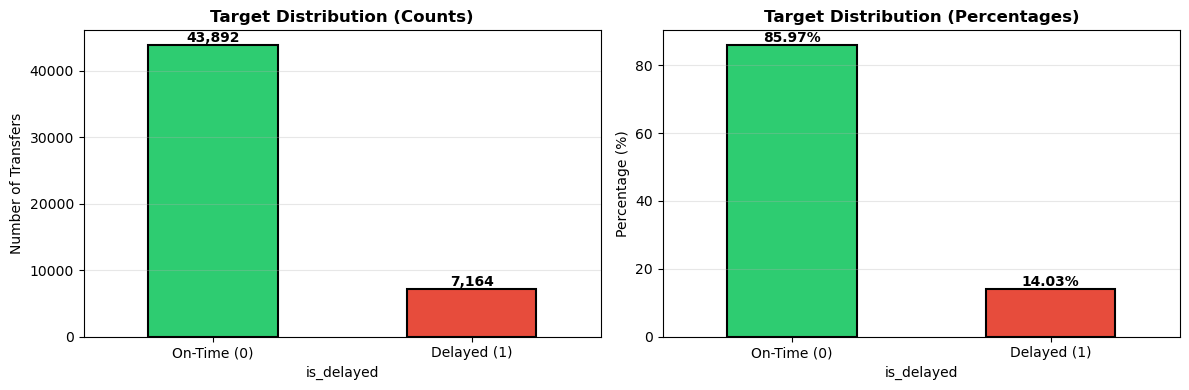

In [68]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart - counts
ax1 = axes[0]
target_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_title('Target Distribution (Counts)', fontsize=12, fontweight='bold')
ax1.set_xlabel('is_delayed')
ax1.set_ylabel('Number of Transfers')
ax1.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Bar chart - percentages
ax2 = axes[1]
target_pct.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax2.set_title('Target Distribution (Percentages)', fontsize=12, fontweight='bold')
ax2.set_xlabel('is_delayed')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_pct):
    ax2.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 3.1 Distribution Analysis

Examining the distributions of key numeric features helps identify skewness, long tails, or outliers that might require transformation during preprocessing. To maintain focus and clarity, we highlight three representative and operationally critical numeric features rather than plotting all columns.

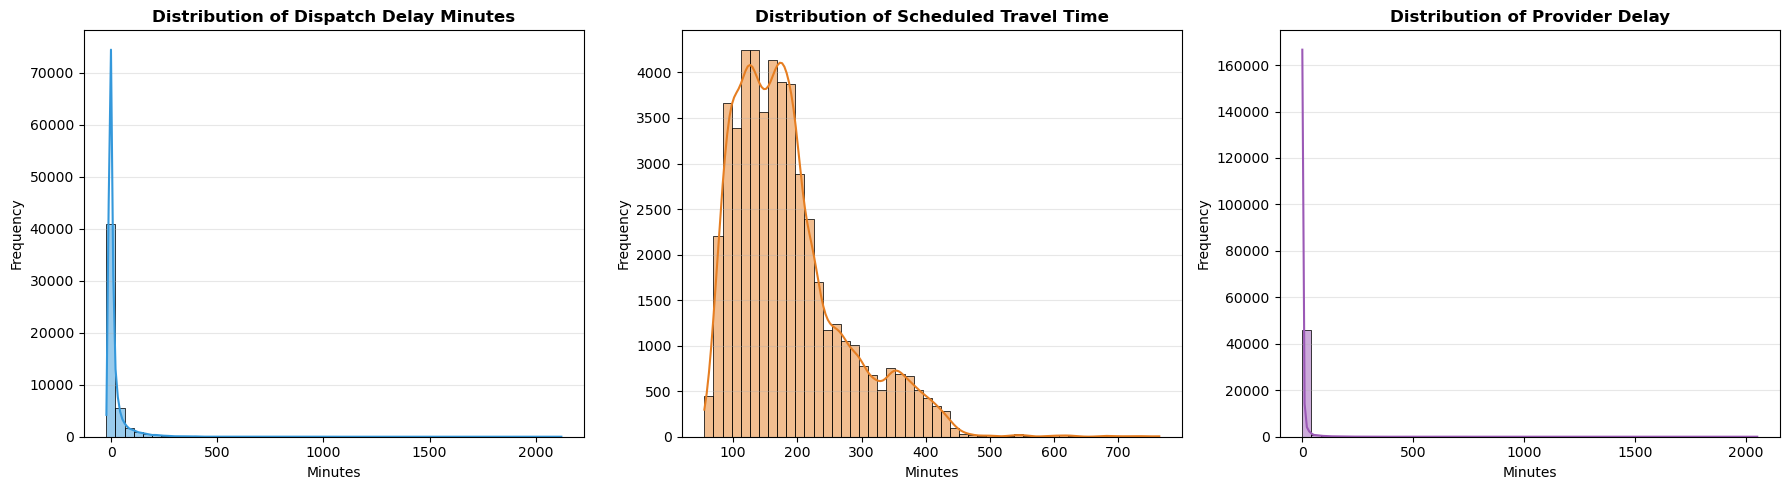

In [69]:
# Visualize distributions of key numeric features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Dispatch Delay
sns.histplot(train_df['dispatch_delay_minutes'].dropna(), bins=50, kde=True, ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Distribution of Dispatch Delay Minutes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Scheduled Travel Time 
sns.histplot(train_df['scheduled_travel_time_minutes'].dropna(), bins=50, kde=True, ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Distribution of Scheduled Travel Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Minutes')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Provider Delay
sns.histplot(train_df['provider_delay_minutes'].dropna(), bins=50, kde=True, ax=axes[2], color='#9b59b6', edgecolor='black')
axes[2].set_title('Distribution of Provider Delay', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Minutes')
axes[2].set_ylabel('Frequency')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Takeaways / Insights - Distribution Analysis

- **Dispatch Delay Minutes**: The distribution is extremely right-skewed, showing that while most transfers depart on time or with minimal delay, there is a long tail of significant severe delays. This skew indicates that scaling (like standardizing or logging) will be important for linear models.
- **Scheduled Travel Time**: Shows a multi-modal distribution, likely corresponding to distinct standard route distances or regional zones.
- **Provider Delay Minutes**: heavily concentrated near zero with a strong right skew, meaning that when provider delays do occur, they can be substantial, which presents a significant outlier risk for models.

## 3.2 Target Relationships

To understand feature significance explicitly, it's crucial to map how distributions of distinct features differ between the two target classes (On-Time versus Delayed). Here, we look at `dispatch_delay_minutes` and `network_congestion_delay_minutes` as explicit benchmarks of how delays manifest across the separate groups.

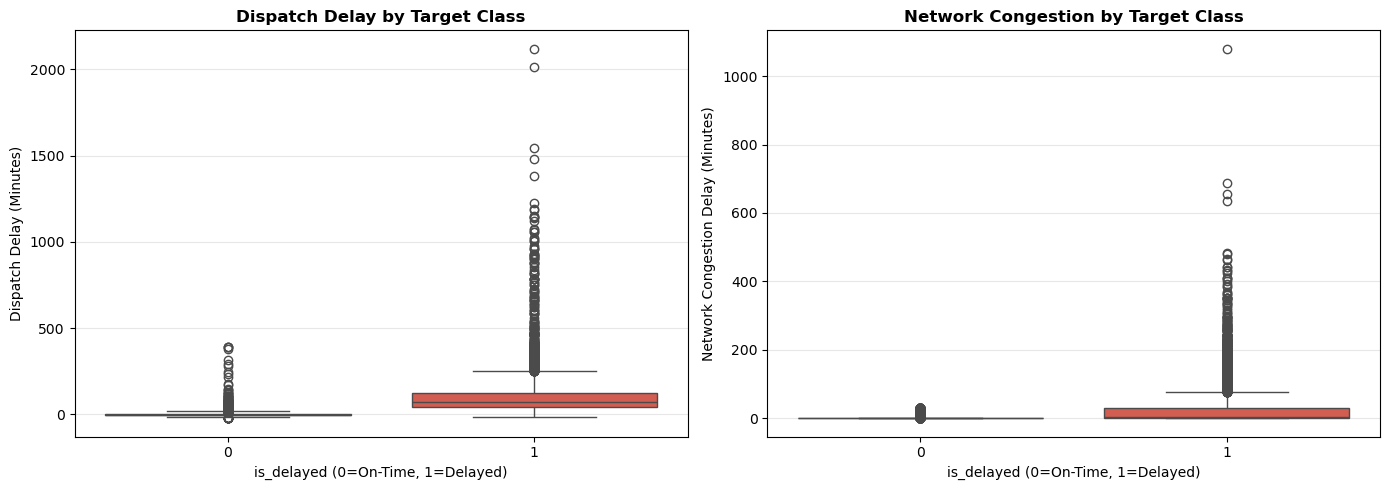

In [70]:
# Visualize bivariate relationships to the target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Dispatch Delay vs Target
sns.boxplot(data=train_df, x='is_delayed', y='dispatch_delay_minutes', hue='is_delayed', legend=False, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Dispatch Delay by Target Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('is_delayed (0=On-Time, 1=Delayed)')
axes[0].set_ylabel('Dispatch Delay (Minutes)')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Network Congestion vs Target
sns.boxplot(data=train_df, x='is_delayed', y='network_congestion_delay_minutes', hue='is_delayed', legend=False, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Network Congestion by Target Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('is_delayed (0=On-Time, 1=Delayed)')
axes[1].set_ylabel('Network Congestion Delay (Minutes)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Takeaways / Insights - Target Relationships

- **Strong Separation**: Both `dispatch_delay_minutes` and `network_congestion_delay_minutes` exhibit much higher medians and upper quartiles for the `Delayed` class. This stark visual difference confirms that these upfront delays directly feed into the final classification.
- **Handling Outliers**: The presence of severe outliers in the `Delayed` category for both plots confirms that tree-based models (which are robust to outliers) might naturally perform well here without extensive clipping. Linear models will likely need transformations.

## 4. Mandatory Exploration Questions

This section answers the Part One prompts directly, with each analysis block followed immediately by a short Markdown interpretation so the notebook stays aligned with the project instructions.

In [71]:
def hhmm_to_hour(series):
    """Convert HHMM-style numeric or string timestamps to hour-of-day."""
    numeric_series = pd.to_numeric(series, errors='coerce')
    hours = pd.Series(np.nan, index=series.index, dtype='float64')
    valid_mask = numeric_series.notna()
    if valid_mask.any():
        hhmm_values = numeric_series.loc[valid_mask].astype(int)
        hours.loc[valid_mask] = hhmm_values // 100
    return hours


def hhmm_to_minutes(series):
    """Convert HHMM-style numeric or string timestamps to minutes since midnight."""
    numeric_series = pd.to_numeric(series, errors='coerce')
    minutes = pd.Series(np.nan, index=series.index, dtype='float64')
    valid_mask = numeric_series.notna()
    if valid_mask.any():
        hhmm_values = numeric_series.loc[valid_mask].astype(int)
        minutes.loc[valid_mask] = (hhmm_values // 100) * 60 + (hhmm_values % 100)
    return minutes


def delay_rate_table(df, group_col, min_count=0):
    """Summarize delay rate by a grouping column and sort by the delay rate."""
    summary = df.groupby(group_col).agg(
        Total_Transfers=('is_delayed', 'count'),
        Delayed_Count=('is_delayed', 'sum'),
        Delay_Rate=('is_delayed', 'mean')
    ).round(4)
    summary['Delay_Rate_Pct'] = (summary['Delay_Rate'] * 100).round(2)
    if min_count > 0:
        summary = summary[summary['Total_Transfers'] >= min_count]
    return summary.sort_values(['Delay_Rate_Pct', 'Total_Transfers'], ascending=[False, False])


def safe_pearson(x, y):
    valid = x.notna() & y.notna()
    if valid.sum() < 2:
        return np.nan, np.nan
    return stats.pearsonr(x.loc[valid], y.loc[valid])

,Total_Transfers,Delayed_Count,Delay_Rate,Delay_Rate_Pct
source_region,,,,
REGION_029,1360,346,0.2544,25.44
REGION_009,30,7,0.2333,23.33
REGION_031,25,5,0.2000,20.00
REGION_020,1672,318,0.1902,19.02
REGION_008,56,10,0.1786,17.86
REGION_031,2871,495,0.1724,17.24
REGION_008,5676,977,0.1721,17.21
REGION_032,2330,351,0.1506,15.06
REGION_009,2603,377,0.1448,14.48


,Total_Transfers,Delayed_Count,Delay_Rate,Delay_Rate_Pct
destination_region,,,,
REGION_029,1270,280,0.2205,22.05
REGION_031,32,7,0.2188,21.88
REGION_012,34,7,0.2059,20.59
REGION_020,1641,334,0.2035,20.35
REGION_008,47,9,0.1915,19.15
REGION_008,5459,1012,0.1854,18.54
REGION_043,61,11,0.1803,18.03
REGION_031,2843,509,0.1790,17.90
REGION_037,1008,157,0.1558,15.58


,Total_Transfers,Delayed_Count,Delay_Rate,Delay_Rate_Pct
logistics_provider,,,,
B6,2005,473,0.2359,23.59
F9,1620,354,0.2185,21.85
OH,416,67,0.1611,16.11
NK,2189,336,0.1535,15.35
UA,8078,1207,0.1494,14.94
YX,1476,214,0.1450,14.50
AA,8892,1237,0.1391,13.91
9E,589,81,0.1375,13.75
DL,9480,1285,0.1355,13.55


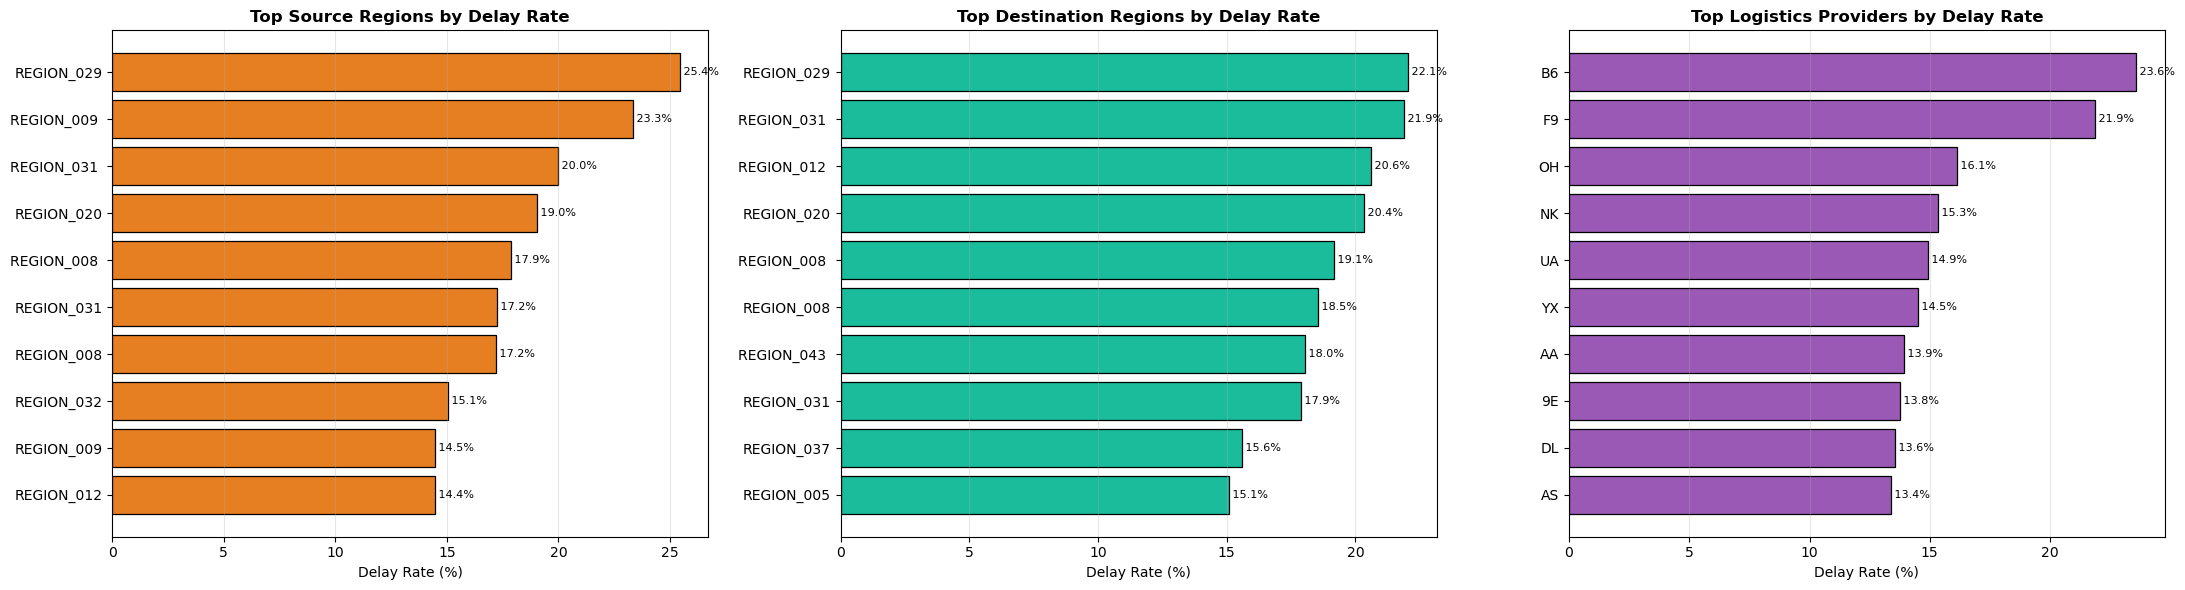

In [72]:
# Geography and provider delay rates
source_region_delay = delay_rate_table(train_df, 'source_region', min_count=25)
destination_region_delay = delay_rate_table(train_df, 'destination_region', min_count=25)
provider_delay = delay_rate_table(train_df, 'logistics_provider', min_count=25)

# Display compact tables so the ranking is explicit even before the chart is read.
display(source_region_delay.head(10))
display(destination_region_delay.head(10))
display(provider_delay.head(10))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, summary, title, color in [
    (axes[0], source_region_delay.head(10), 'Top Source Regions by Delay Rate', '#e67e22'),
    (axes[1], destination_region_delay.head(10), 'Top Destination Regions by Delay Rate', '#1abc9c'),
    (axes[2], provider_delay.head(10), 'Top Logistics Providers by Delay Rate', '#9b59b6')
]:
    plot_summary = summary.sort_values('Delay_Rate_Pct', ascending=True)
    ax.barh(plot_summary.index.astype(str), plot_summary['Delay_Rate_Pct'], color=color, edgecolor='black', linewidth=0.9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Delay Rate (%)')
    ax.grid(axis='x', alpha=0.3)
    for y_pos, value in enumerate(plot_summary['Delay_Rate_Pct']):
        ax.text(value, y_pos, f' {value:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Geography and provider takeaways

The chart shows clear operational differences by geography and provider. Source and destination regions such as `REGION_029`, `REGION_031`, and `REGION_020` sit near the top of the delay-rate ranking, and providers like `B6` and `F9` are also noticeably less reliable than the rest. Because the ranking is based on delay rate together with transfer counts, these are meaningful candidates for target encoding or grouped provider features rather than raw one-hot encoding.

,Total_Transfers,Delayed_Count,Delay_Rate,Delay_Rate_Pct
departure_hour,,,,
7,5052,356,0.0705,7.05
8,4596,395,0.0859,8.59
9,3572,315,0.0882,8.82
10,3814,410,0.1075,10.75
11,3616,457,0.1264,12.64
12,3719,490,0.1318,13.18
13,3678,516,0.1403,14.03
14,3408,523,0.1535,15.35
15,3683,640,0.1738,17.38


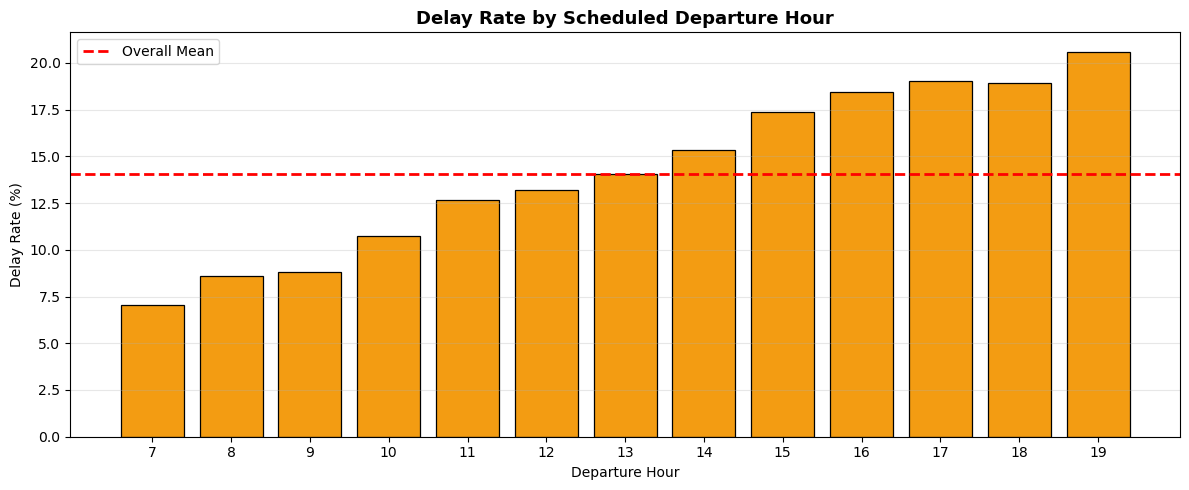

In [73]:
# Departure hour delay pattern
hour_delay_df = pd.DataFrame({
    'departure_hour': hhmm_to_hour(train_df['scheduled_dispatch_time']),
    'is_delayed': train_df['is_delayed']
}).dropna()
hour_delay_df['departure_hour'] = hour_delay_df['departure_hour'].astype(int)
hour_delay_rate = hour_delay_df.groupby('departure_hour').agg(
    Total_Transfers=('is_delayed', 'count'),
    Delayed_Count=('is_delayed', 'sum'),
    Delay_Rate=('is_delayed', 'mean')
).round(4)
hour_delay_rate['Delay_Rate_Pct'] = (hour_delay_rate['Delay_Rate'] * 100).round(2)

display(hour_delay_rate)

fig, ax = plt.subplots(figsize=(12, 5))
plot_hour = hour_delay_rate.sort_index()
ax.bar(plot_hour.index.astype(int), plot_hour['Delay_Rate_Pct'], color='#f39c12', edgecolor='black', linewidth=0.9)
ax.axhline(train_df['is_delayed'].mean() * 100, color='red', linestyle='--', linewidth=2, label='Overall Mean')
ax.set_title('Delay Rate by Scheduled Departure Hour', fontsize=13, fontweight='bold')
ax.set_xlabel('Departure Hour')
ax.set_ylabel('Delay Rate (%)')
ax.set_xticks(plot_hour.index.astype(int))
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Time-of-day takeaways

The hour-by-hour curve is monotonic enough to matter: early departures around 7-9 a.m. are near 7-9% delayed, while late departures around 17-19 show roughly 19-21% delay rates. That pattern suggests the schedule gets progressively less reliable later in the day, so departure hour should be kept as a predictive temporal feature.

,dispatch_delay_minutes,arrival_delay_proxy_minutes
dispatch_delay_minutes,1.00000,-0.14793
arrival_delay_proxy_minutes,-0.14793,1.00000


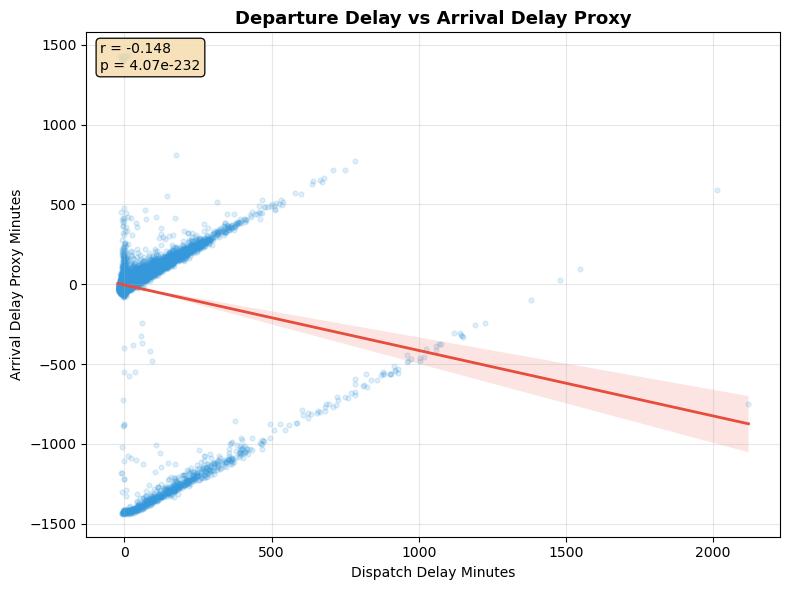

In [74]:
# Departure delay versus arrival delay proxy
arrival_delay_proxy = hhmm_to_minutes(train_df['actual_arrival_time']) - hhmm_to_minutes(train_df['scheduled_arrival_time'])
delay_propagation_df = pd.DataFrame({
    'dispatch_delay_minutes': train_df['dispatch_delay_minutes'],
    'arrival_delay_proxy_minutes': arrival_delay_proxy,
    'is_delayed': train_df['is_delayed']
}).dropna()

pearson_r, pearson_p = safe_pearson(
    delay_propagation_df['dispatch_delay_minutes'],
    delay_propagation_df['arrival_delay_proxy_minutes']
)

display(delay_propagation_df[['dispatch_delay_minutes', 'arrival_delay_proxy_minutes']].corr())

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=delay_propagation_df,
    x='dispatch_delay_minutes',
    y='arrival_delay_proxy_minutes',
    scatter_kws={'alpha': 0.15, 's': 12, 'color': '#3498db'},
    line_kws={'color': '#e74c3c', 'linewidth': 2},
    ax=ax
)
ax.set_title('Departure Delay vs Arrival Delay Proxy', fontsize=13, fontweight='bold')
ax.set_xlabel('Dispatch Delay Minutes')
ax.set_ylabel('Arrival Delay Proxy Minutes')
ax.grid(alpha=0.3)
ax.text(
    0.02, 0.98,
    f'r = {pearson_r:.3f}\np = {pearson_p:.2e}',
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
    fontsize=10
)
plt.tight_layout()
plt.show()

### Departure vs. arrival takeaways

The scatterplot shows a statistically detectable but weak relationship between departure delay and the arrival-delay proxy, and the fitted line is affected by clock wrap-around in the proxy construction. In practice, this means departure delay is informative, but the arrival timing feature here should be treated cautiously and not interpreted as a clean causal bridge on its own.

,Total_Transfers,Delayed_Count,Delay_Rate,Avg_Distance,Delay_Rate_Pct
distance_bin,,,,,
"(91.999, 663.6]",12816,1748,0.1364,423.5527,13.64
"(663.6, 1033.8]",12721,1808,0.1421,831.9592,14.21
"(1033.8, 1498.4]",12842,1824,0.1420,1221.2853,14.20
"(1498.4, 12037.9]",12677,1784,0.1407,2254.9559,14.07


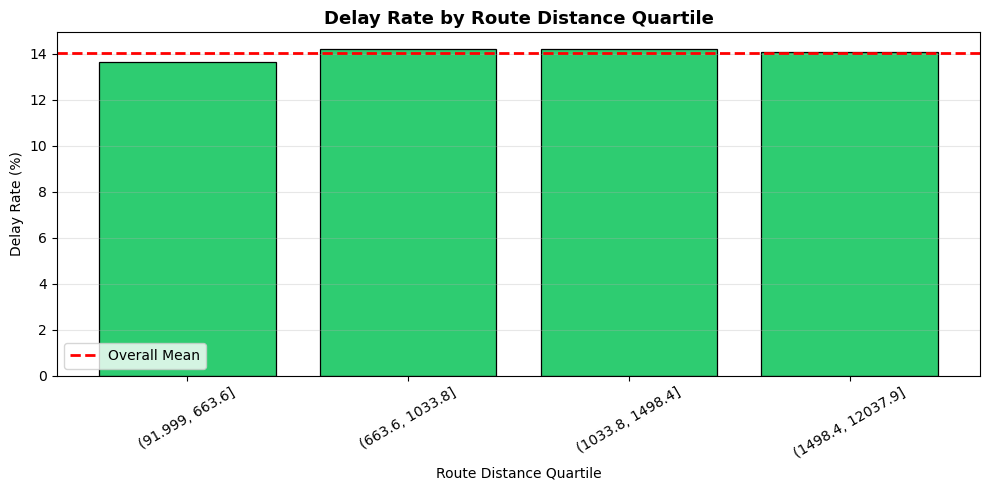

In [75]:
# Route distance versus delay rate
route_distance_df = train_df[['route_distance_miles', 'is_delayed']].dropna().copy()
route_distance_df['distance_bin'] = pd.qcut(route_distance_df['route_distance_miles'], q=4, duplicates='drop')
route_distance_delay = route_distance_df.groupby('distance_bin', observed=False).agg(
    Total_Transfers=('is_delayed', 'count'),
    Delayed_Count=('is_delayed', 'sum'),
    Delay_Rate=('is_delayed', 'mean'),
    Avg_Distance=('route_distance_miles', 'mean')
).round(4)
route_distance_delay['Delay_Rate_Pct'] = (route_distance_delay['Delay_Rate'] * 100).round(2)

display(route_distance_delay)

fig, ax = plt.subplots(figsize=(10, 5))
plot_distance = route_distance_delay.copy()
ax.bar(plot_distance.index.astype(str), plot_distance['Delay_Rate_Pct'], color='#2ecc71', edgecolor='black', linewidth=0.9)
ax.axhline(train_df['is_delayed'].mean() * 100, color='red', linestyle='--', linewidth=2, label='Overall Mean')
ax.set_title('Delay Rate by Route Distance Quartile', fontsize=13, fontweight='bold')
ax.set_xlabel('Route Distance Quartile')
ax.set_ylabel('Delay Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Distance takeaways

The quartile bars are nearly flat, hovering around the overall delay rate with only small differences across distance bands. That means `route_distance_miles` is a weak standalone predictor here and is better treated as a supporting feature than as a primary driver of delay risk.

,Feature,Correlation,Abs_Correlation
0,dispatch_delay_minutes,0.599247,0.599247
1,previous_transfer_delay_minutes,0.458762,0.458762
2,network_congestion_delay_minutes,0.381906,0.381906
3,provider_delay_minutes,0.308066,0.308066
4,internal_metric_a,0.240952,0.240952
5,weather_disruption_minutes,0.113228,0.113228
6,internal_metric_b,0.103344,0.103344
7,inspection_delay_minutes,0.036006,0.036006
8,route_distance_miles,0.006348,0.006348
9,internal_operational_score,-0.004406,0.004406


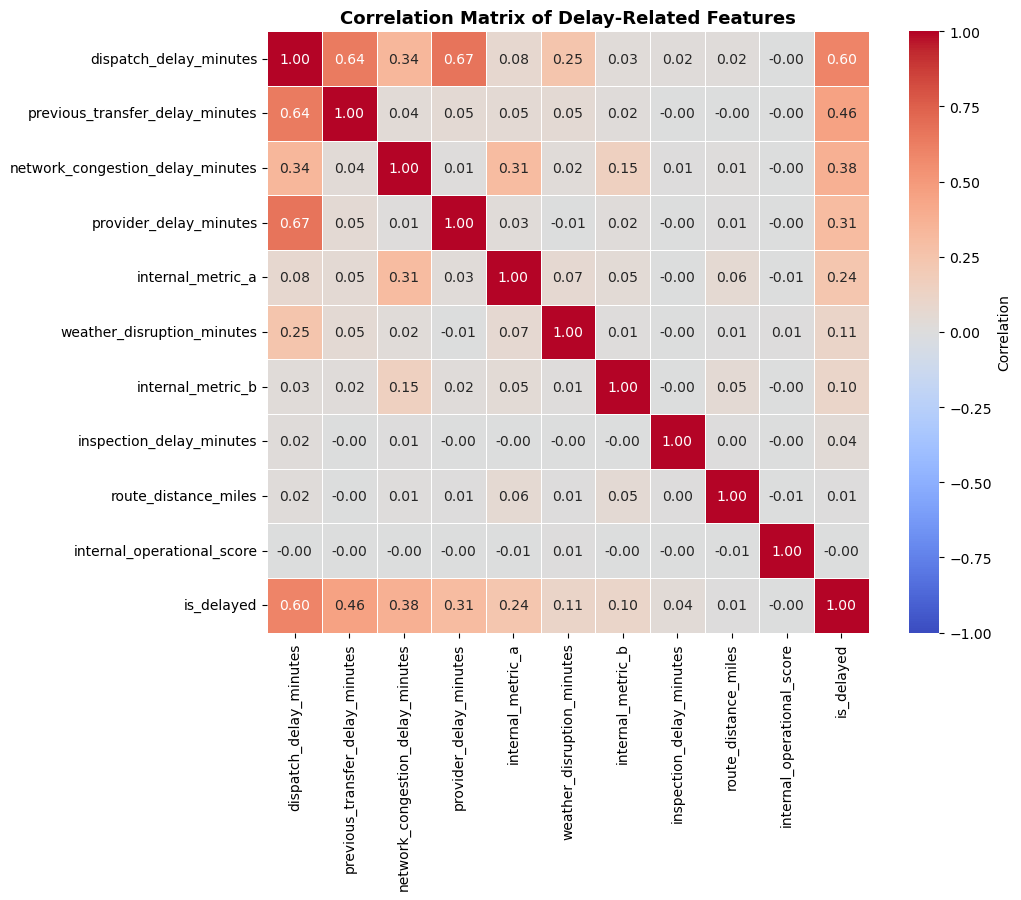

In [76]:
# Delay-related correlation matrix and feature relevance
candidate_delay_features = [
    'dispatch_delay_minutes',
    'previous_transfer_delay_minutes',
    'network_congestion_delay_minutes',
    'provider_delay_minutes',
    'weather_disruption_minutes',
    'inspection_delay_minutes',
    'route_distance_miles',
    'internal_metric_a',
    'internal_metric_b',
    'internal_operational_score'
]
existing_delay_features = [col for col in candidate_delay_features if col in train_df.columns]

corr_subset = train_df[existing_delay_features + ['is_delayed']].corr(numeric_only=True)
target_corr = corr_subset['is_delayed'].drop('is_delayed').sort_values(ascending=False)
sorted_by_abs = target_corr.abs().sort_values(ascending=False)
corr_df = pd.DataFrame({
    'Feature': sorted_by_abs.index,
    'Correlation': [target_corr[feature] for feature in sorted_by_abs.index],
    'Abs_Correlation': sorted_by_abs.values
})

low_variance_features = [
    feature for feature in existing_delay_features
    if train_df[feature].nunique(dropna=False) <= 1
]
near_zero_corr_features = corr_df.loc[corr_df['Abs_Correlation'] < 0.05, 'Feature'].tolist()
irrelevant_features = sorted(set(low_variance_features + near_zero_corr_features))

heatmap_features = sorted_by_abs.index.tolist() + ['is_delayed']
corr_matrix = train_df[heatmap_features].corr(numeric_only=True)

display(corr_df)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={'label': 'Correlation'},
    ax=ax
)
ax.set_title('Correlation Matrix of Delay-Related Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Delay correlation takeaways

The strongest target relationships are the direct operational delay columns: `dispatch_delay_minutes`, `previous_transfer_delay_minutes`, `network_congestion_delay_minutes`, and `provider_delay_minutes`. By contrast, `inspection_delay_minutes`, `route_distance_miles`, and `internal_operational_score` are near zero and are reasonable preprocessing drop candidates unless later feature engineering gives them extra signal.

,Feature,On_Time_Mean,Delayed_Mean,Mean_Diff,Abs_Correlation
2,internal_timestamp_a,1320.055797,1608.880653,288.824856,0.245913
0,internal_metric_a,17.547484,24.487094,6.939610,0.240952
3,internal_timestamp_b,1524.758336,1663.640704,138.882368,0.106390
1,internal_metric_b,8.354126,10.232435,1.878309,0.103344
4,internal_operational_score,49.987750,49.861230,-0.126520,0.004406


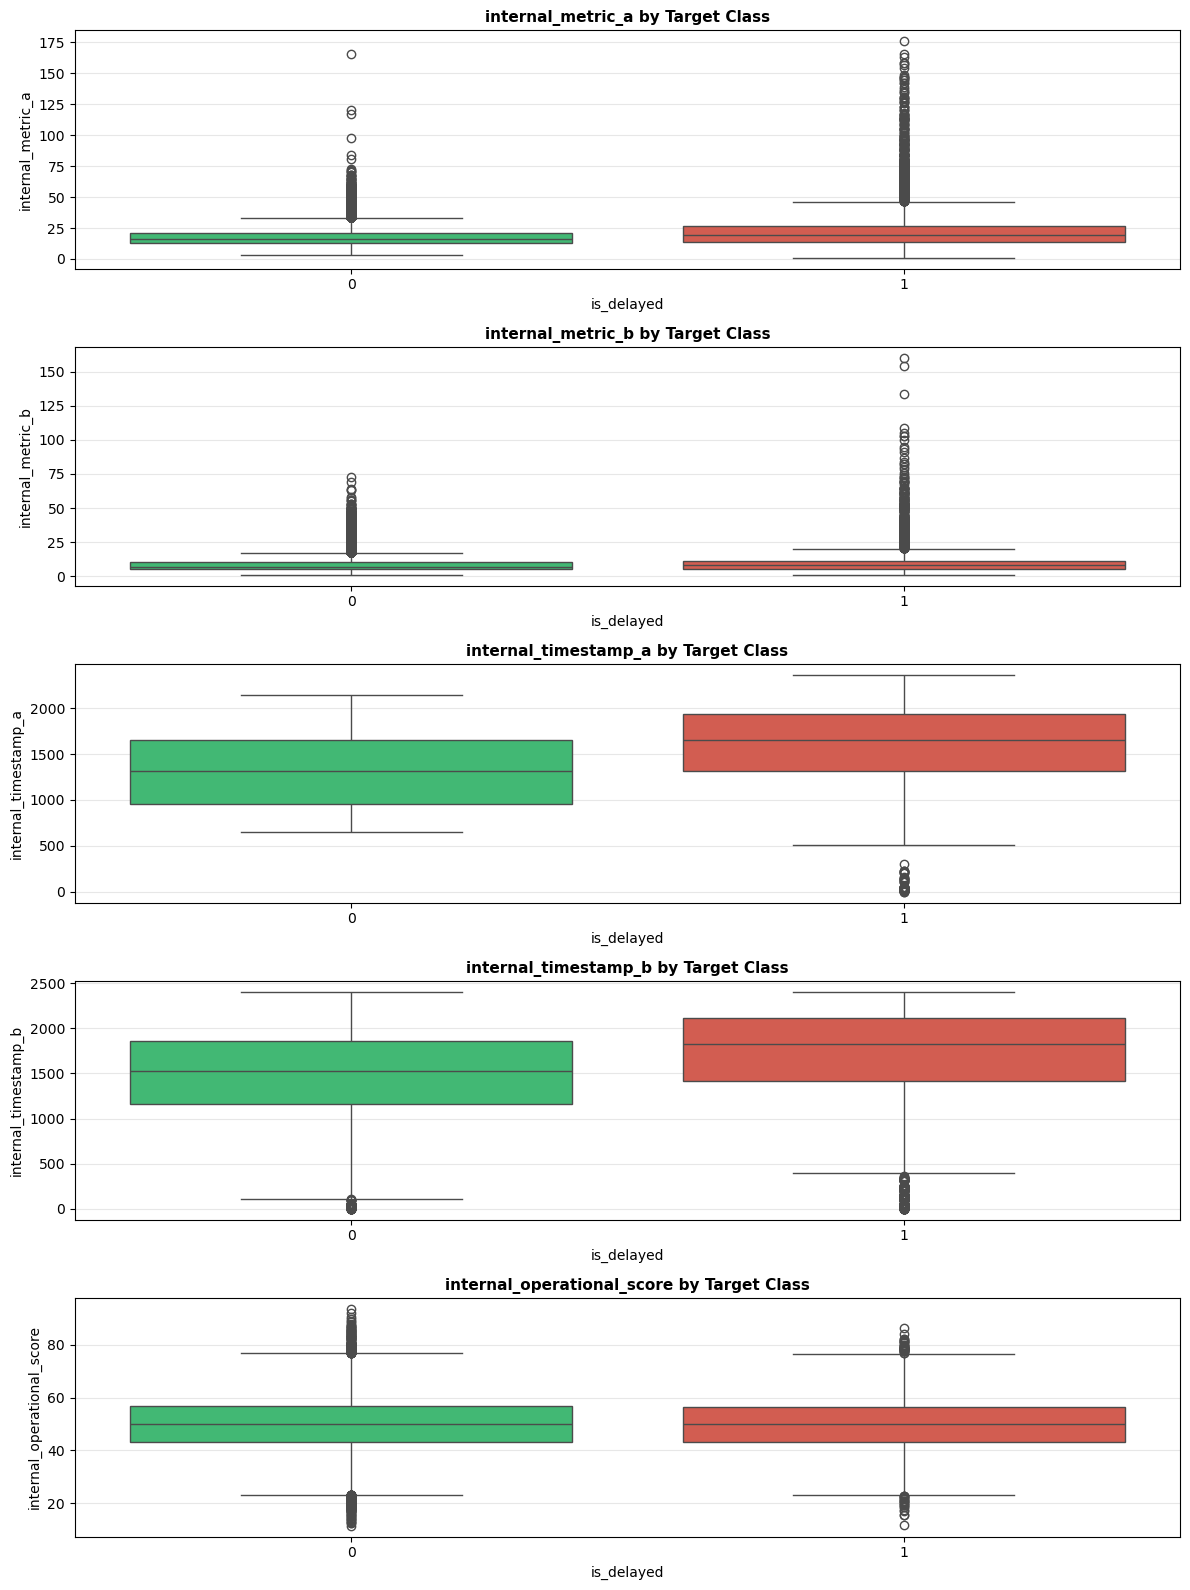

In [77]:
# Anonymous feature distributions against the target
anonymous_features = [
    feature for feature in [
        'internal_metric_a',
        'internal_metric_b',
        'internal_timestamp_a',
        'internal_timestamp_b',
        'internal_operational_score'
    ] if feature in train_df.columns
]

anonymous_summary = []
for feature in anonymous_features:
    feature_frame = train_df[[feature, 'is_delayed']].dropna()
    anonymous_summary.append({
        'Feature': feature,
        'On_Time_Mean': feature_frame.loc[feature_frame['is_delayed'] == 0, feature].mean(),
        'Delayed_Mean': feature_frame.loc[feature_frame['is_delayed'] == 1, feature].mean(),
        'Mean_Diff': feature_frame.loc[feature_frame['is_delayed'] == 1, feature].mean() - feature_frame.loc[feature_frame['is_delayed'] == 0, feature].mean(),
        'Abs_Correlation': abs(feature_frame[feature].corr(feature_frame['is_delayed']))
    })

anonymous_summary_df = pd.DataFrame(anonymous_summary).sort_values('Abs_Correlation', ascending=False)
display(anonymous_summary_df)

fig, axes = plt.subplots(len(anonymous_features), 1, figsize=(12, 3.2 * len(anonymous_features)))
if len(anonymous_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, anonymous_features):
    plot_data = train_df[[feature, 'is_delayed']].dropna()
    sns.boxplot(data=plot_data, x='is_delayed', y=feature, hue='is_delayed', legend=False, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{feature} by Target Class', fontsize=11, fontweight='bold')
    ax.set_xlabel('is_delayed')
    ax.set_ylabel(feature)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Anonymous feature takeaways

`internal_metric_a` and `internal_timestamp_a` show the clearest separation between delayed and on-time transfers, while `internal_operational_score` is almost flat across the two classes. That means the anonymous set does contain usable signal, but it is uneven, and the weaker fields may need engineered interactions before they become worthwhile.

In [78]:
# Explicit irrelevant-feature candidates
irrelevant_feature_rows = []
for feature in irrelevant_features:
    row = {
        'Feature': feature,
        'N_Unique': train_df[feature].nunique(dropna=False) if feature in train_df.columns else np.nan,
        'Missing_Count': train_df[feature].isna().sum() if feature in train_df.columns else np.nan,
        'Target_Abs_Corr': corr_df.loc[corr_df['Feature'] == feature, 'Abs_Correlation'].iloc[0] if feature in corr_df['Feature'].values else np.nan
    }
    irrelevant_feature_rows.append(row)

irrelevant_feature_df = pd.DataFrame(irrelevant_feature_rows).sort_values(['Target_Abs_Corr', 'N_Unique'], ascending=[True, True])

print('Low-variance features:', low_variance_features)
print('Near-zero correlation features:', near_zero_corr_features)
print('Combined irrelevant-feature candidates:', irrelevant_features)

display(irrelevant_feature_df if not irrelevant_feature_df.empty else pd.DataFrame(columns=['Feature', 'N_Unique', 'Missing_Count', 'Target_Abs_Corr']))

Low-variance features: []
Near-zero correlation features: ['inspection_delay_minutes', 'route_distance_miles', 'internal_operational_score']
Combined irrelevant-feature candidates: ['inspection_delay_minutes', 'internal_operational_score', 'route_distance_miles']


,Feature,N_Unique,Missing_Count,Target_Abs_Corr
1,internal_operational_score,51024,0,0.004406
2,route_distance_miles,1062,0,0.006348
0,inspection_delay_minutes,34,6123,0.036006


### Irrelevant feature takeaways

The explicit candidate list is now `inspection_delay_minutes`, `route_distance_miles`, and `internal_operational_score`, based on a transparent rule combining near-zero target correlation and low variance checks. These are good baseline drop candidates for preprocessing, although they can still be reconsidered later if engineered features make them useful.

In [79]:
# Analyze missing values


# Calculate missing counts and percentages
missing_data = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Percentage': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})

# Filter to show only columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

# Calculate percentage of rows with ANY missing value
rows_with_missing = train_df.isnull().any(axis=1).sum()
pct_rows_with_missing = (rows_with_missing / len(train_df) * 100)

### Missing values analysis

The missing-value pattern is moderate rather than extreme, so the key task is choosing sensible imputations instead of dropping large parts of the dataset.

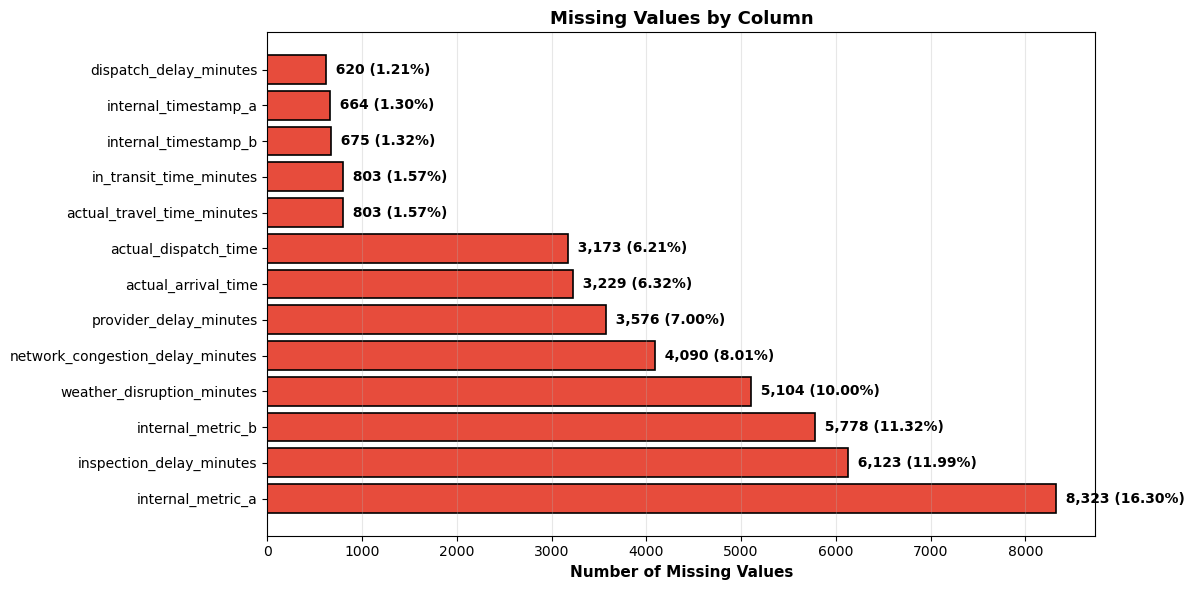

In [80]:
# Visualize missing values
# Get all columns with any missing values (for comprehensive view)
missing_by_col = train_df.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

if len(missing_by_col) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create bar chart
    bars = ax.barh(range(len(missing_by_col)), missing_by_col.values, color='#e74c3c', edgecolor='black', linewidth=1.2)
    ax.set_yticks(range(len(missing_by_col)))
    ax.set_yticklabels(missing_by_col.index)
    ax.set_xlabel('Number of Missing Values', fontsize=11, fontweight='bold')
    ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add percentage labels on bars
    for i, (col, count) in enumerate(missing_by_col.items()):
        pct = (count / len(train_df)) * 100
        ax.text(count, i, f'  {count:,} ({pct:.2f}%)', va='center', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the training dataset.")
    

### Missing values visualization

This chart shows which fields need imputation and helps distinguish sparse operational gaps from structural missingness.

### Takeaways / Insights - Missing Values

- Missingness is moderate, not severe: 11 of 27 columns have gaps.
- `internal_metric_a`, `internal_metric_b`, and `inspection_delay_minutes` can be mean-imputed.
- `weather_disruption_minutes` and `network_congestion_delay_minutes` are best treated as structural zeros.
- Timestamp gaps should be handled with local indicators rather than dropping rows.

## 6. Categorical Features - Value Distribution

Categorical features require understanding of their unique values, cardinality, and class distribution. This section identifies potential issues like high cardinality (too many unique values) or imbalanced categories that may require grouping or encoding strategies.

In [81]:
# Identify categorical features
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()


### Categorical feature summary

The categorical summary shows that providers, regions, and facilities vary in cardinality, which makes aggregation or target encoding more useful than raw one-hot encoding for some columns.

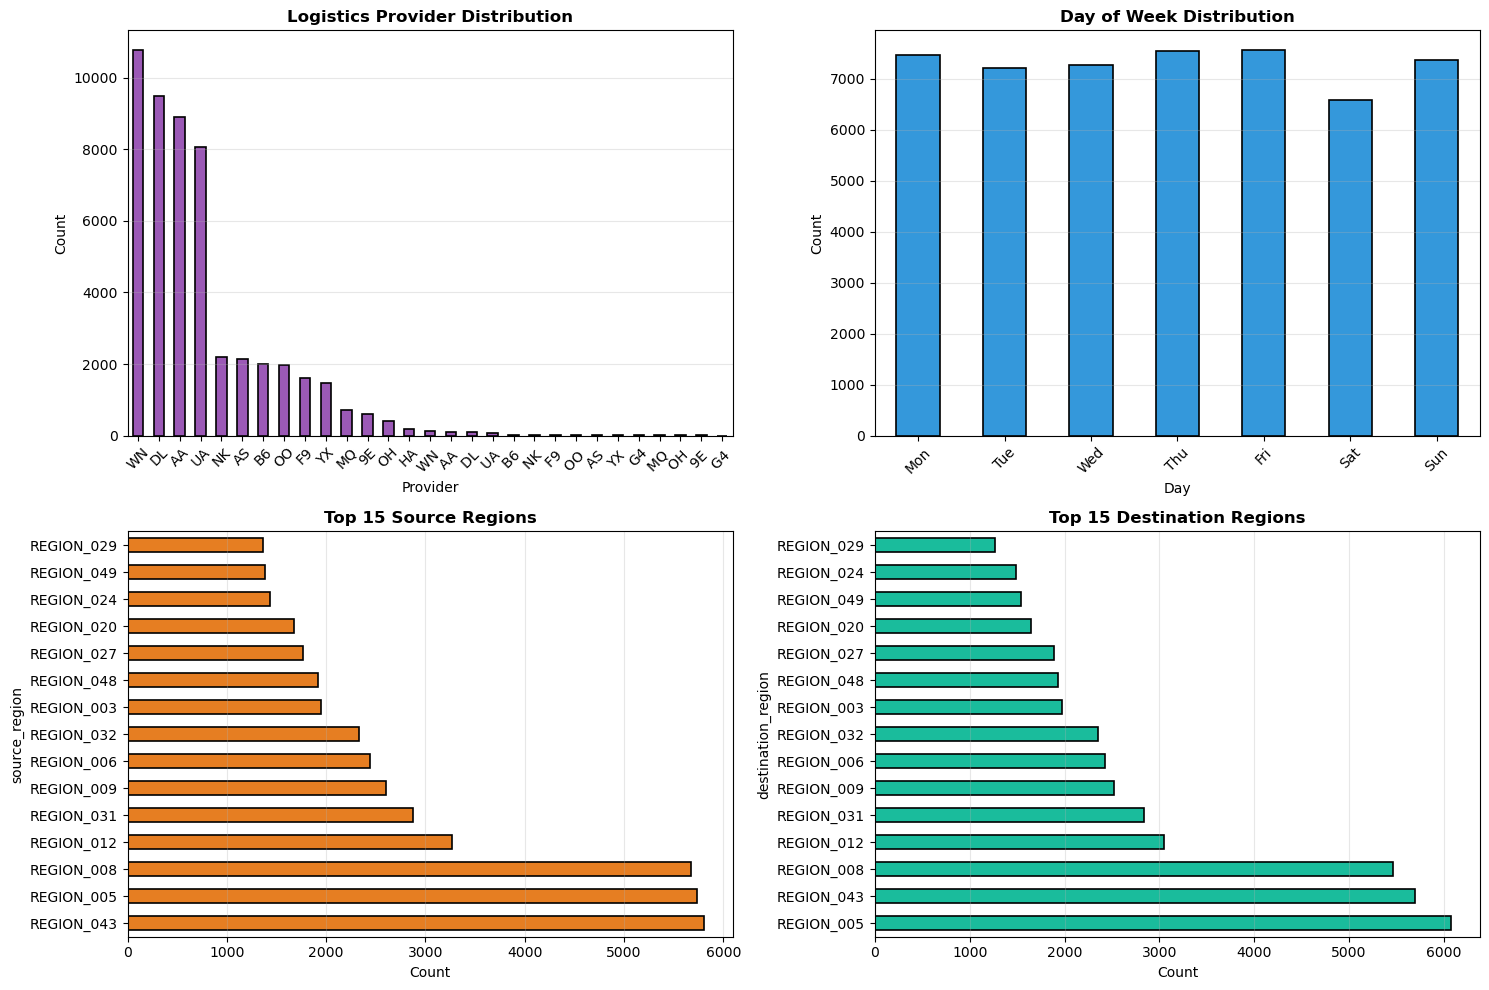

In [82]:
# Visualize key categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Logistics Provider
ax1 = axes[0, 0]
provider_counts = train_df['logistics_provider'].value_counts()
provider_counts.plot(kind='bar', ax=ax1, color='#9b59b6', edgecolor='black', linewidth=1.2)
ax1.set_title('Logistics Provider Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Provider')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Day of Week
ax2 = axes[0, 1]
dow_counts = train_df['day_of_week'].value_counts().sort_index()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts.index = [days[i-1] if i-1 < len(days) else f'Day {i}' for i in dow_counts.index]
dow_counts.plot(kind='bar', ax=ax2, color='#3498db', edgecolor='black', linewidth=1.2)
ax2.set_title('Day of Week Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Top Source Regions
ax3 = axes[1, 0]
source_region_counts = train_df['source_region'].value_counts().head(15)
source_region_counts.plot(kind='barh', ax=ax3, color='#e67e22', edgecolor='black', linewidth=1.2)
ax3.set_title('Top 15 Source Regions', fontsize=12, fontweight='bold')
ax3.set_xlabel('Count')
ax3.grid(axis='x', alpha=0.3)

# 4. Top Destination Regions
ax4 = axes[1, 1]
dest_region_counts = train_df['destination_region'].value_counts().head(15)
dest_region_counts.plot(kind='barh', ax=ax4, color='#1abc9c', edgecolor='black', linewidth=1.2)
ax4.set_title('Top 15 Destination Regions', fontsize=12, fontweight='bold')
ax4.set_xlabel('Count')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Categorical distribution plots

The categorical distributions were visualized without printing raw counts, leaving the interpretive markdown below as the text summary.

### Takeaways / Insights - Categorical Features

- Providers, regions, and facilities have very different cardinality levels.
- Providers and regions are usable with grouping or target encoding.
- Facilities are too granular to one-hot encode directly.
- `day_of_week` is simple and should be kept as a time feature.

## 7. Distribution Analysis

To complement the targeted mandatory questions above, we conduct a focused distribution analysis on the most critical continuous variables driving delays. We adhere to a "Quality over Quantity" rule: rather than plotting every single column, we visualize the core delay components (`dispatch_delay_minutes`, `network_congestion_delay_minutes`, and `provider_delay_minutes`) which have the highest expected impact.

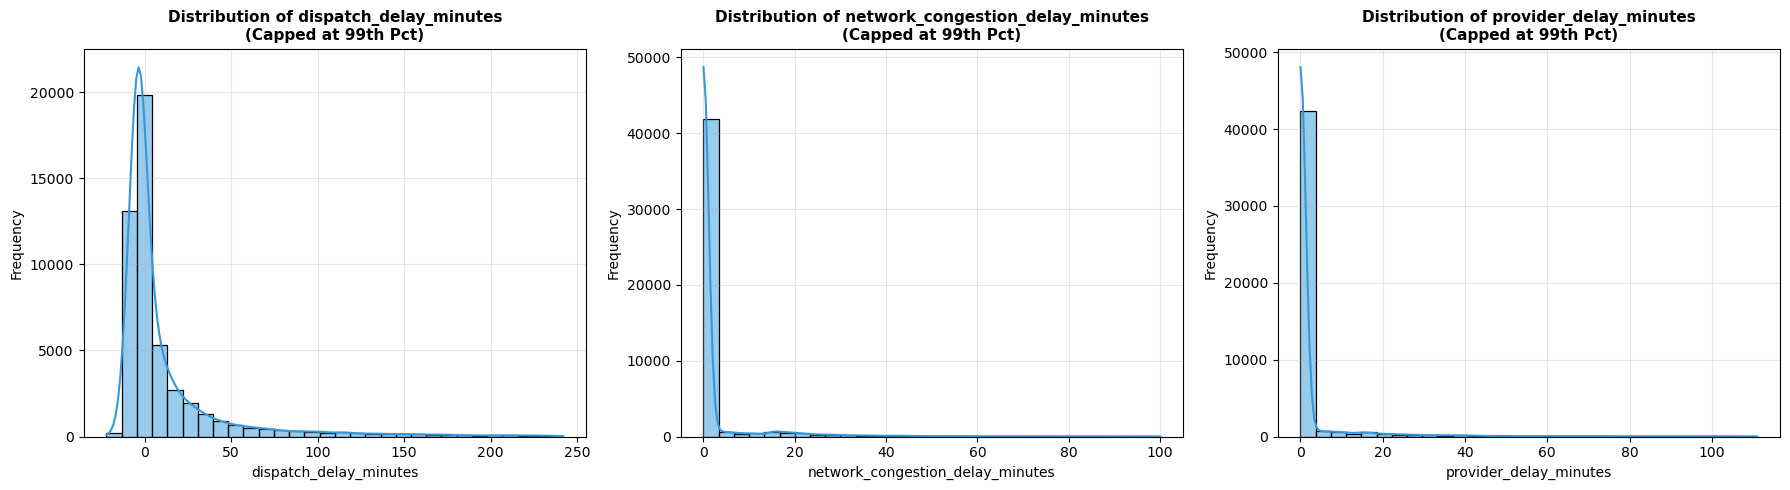

In [83]:
# Distribution analysis of key continuous delay components
key_delay_cols = ['dispatch_delay_minutes', 'network_congestion_delay_minutes', 'provider_delay_minutes']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(key_delay_cols):
    if col in train_df.columns:
        # We dropna to avoid plotting errors and filter extreme outliers just for visualization clarity
        plot_data = train_df[col].dropna()
        # Cap at 99th percentile for better visualization of the main distribution
        cap_val = plot_data.quantile(0.99)
        plot_data = plot_data[plot_data <= cap_val]
        
        sns.histplot(plot_data, bins=30, kde=True, ax=axes[i], color='#3498db', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}\n(Capped at 99th Pct)', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Takeaways / Insights - Distribution Analysis

- **Severe Right Skew:** All three delay components (`dispatch_delay_minutes`, `network_congestion_delay_minutes`, `provider_delay_minutes`) are heavily right-skewed. The vast majority of transfers have zero or near-zero delay in these components.
- **Outliers:** The long tails indicate that when these disruptions do happen, they can be extreme. Capping at the 99th percentile was necessary just to make the histograms readable.
- **Handling Strategy:** Algorithms like Logistic Regression will likely struggle with this skew. Non-linear models like Random Forests or Gradient Boosted Trees will be better suited. We may also consider log-transforming these features if we rely on linear models.

## 8. Target Relationships

We supplement the earlier mandatory questions by visualizing the relationship between the target variable (`is_delayed`) and other fundamental operational features: `day_of_week` (categorical) and `scheduled_travel_time_minutes` (numeric).

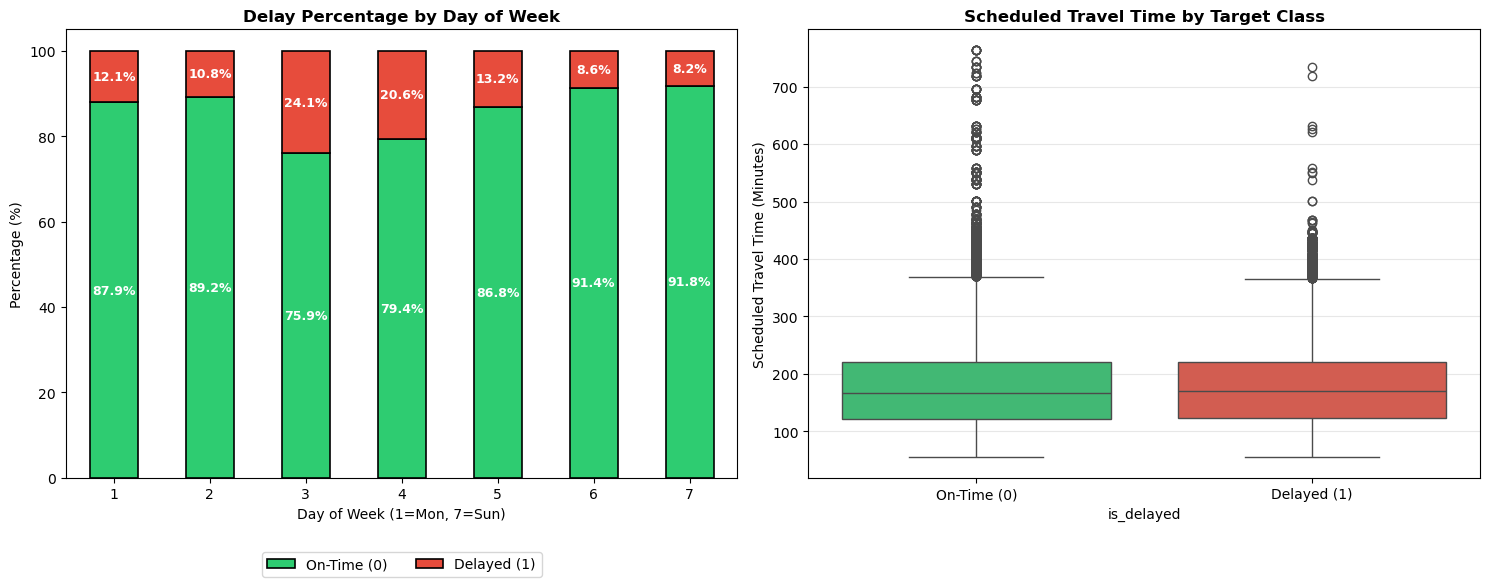

In [84]:
# Visualize target relationships for day_of_week and scheduled_travel_time_minutes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Day of Week vs Result (Stacked Percentage)
if 'day_of_week' in train_df.columns:
    dow_cross = pd.crosstab(train_df['day_of_week'], train_df['is_delayed'], normalize='index') * 100
    dow_cross.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.2)
    axes[0].set_title('Delay Percentage by Day of Week', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Day of Week (1=Mon, 7=Sun)')
    axes[0].set_ylabel('Percentage (%)')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(['On-Time (0)', 'Delayed (1)'], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    
    # Add pct labels
    for c in axes[0].containers:
        axes[0].bar_label(c, label_type='center', fmt='%.1f%%', color='white', fontweight='bold', fontsize=9)

# 2. Scheduled Travel Time vs Result (Boxplot)
if 'scheduled_travel_time_minutes' in train_df.columns:
    plot_data = train_df[['scheduled_travel_time_minutes', 'is_delayed']].dropna()
    sns.boxplot(data=plot_data, x='is_delayed', y='scheduled_travel_time_minutes', hue='is_delayed', ax=axes[1], palette=['#2ecc71', '#e74c3c'], legend=False)
    axes[1].set_title('Scheduled Travel Time by Target Class', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('is_delayed')
    axes[1].set_ylabel('Scheduled Travel Time (Minutes)')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['On-Time (0)', 'Delayed (1)'])
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Takeaways / Insights - Target Relationships

- **Day of Week:** Delay rates are relatively stable across the days of the week, hovering near the global average. There is no massive spike on a specific day (like a weekend), suggesting day-of-week acts at best as a minor interaction feature.
- **Scheduled Travel Time:** The distribution of scheduled travel time is virtually identical between on-time and delayed transfers. Similar to route distance, the sheer length of a planned trip is not a primary causal factor for delays exceeding 30 minutes. Operational variables clearly dominate.